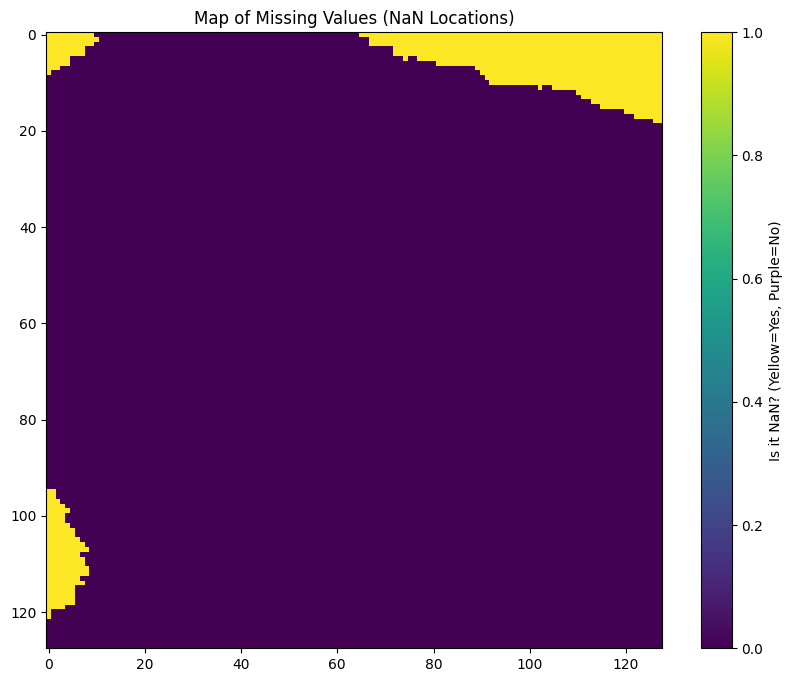

In [36]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取数据
ds = xr.open_dataset('./data/mini_dataset_new.nc')

# 2. 挑一个肯定有问题的变量，比如 NDVI
# 取第0天的数据
sample_data = ds['ndvi'].isel(time=10) #取变量ndvi,fwi,max_wind_speed,max_t2m

# 3. 制作一张“侦探图”
# 如果是 NaN，就是 True (黄色/亮色)
# 如果有值，就是 False (紫色/暗色)
nan_mask = np.isnan(sample_data.values)

# 4. 画图
plt.figure(figsize=(10, 8))
plt.imshow(nan_mask, cmap='viridis')
plt.colorbar(label='Is it NaN? (Yellow=Yes, Purple=No)')
plt.title("Map of Missing Values (NaN Locations)")
plt.show()

In [8]:
import xarray as xr

ds = xr.open_dataset('./data/mini_dataset.nc')

print("=== 变量维度检查 ===")
for var in ['ndvi', 'max_t2m', 'burned_areas']:
    print(f"变量 [{var}] 的维度: {ds[var].dims}")
    print(f"变量 [{var}] 的坐标: {list(ds[var].coords)}")
    print("-" * 20)

=== 变量维度检查 ===
变量 [ndvi] 的维度: ('time', 'y', 'x')
变量 [ndvi] 的坐标: ['time', 'x', 'y', 'band', 'spatial_ref']
--------------------
变量 [max_t2m] 的维度: ('time', 'y', 'x')
变量 [max_t2m] 的坐标: ['time', 'x', 'y', 'band', 'spatial_ref']
--------------------
变量 [burned_areas] 的维度: ('time', 'y', 'x')
变量 [burned_areas] 的坐标: ['time', 'x', 'y', 'band', 'spatial_ref']
--------------------


In [38]:
import xarray as xr
import numpy as np

input_file = './data/dataset_greece.nc'
output_file = './data/mini_dataset.nc'  # 改个名字，叫 year

print("🚀 正在制作【全年】玩具数据集...")

# 1. 读取
ds = xr.open_dataset(input_file)

# 2. 核心切片：时间改成了 "2021" (代表2021全年)
# 空间范围我帮你选了一个陆地比较多的区域 (x:300-428, y:500-628)
# 也就是 128x128 大小
print("正在切片 (2021全年 + 纯陆地区域)...")
mini_ds = ds.sel(time="2021").isel(x=slice(360, 488), y=slice(500, 628))

# 3. 修复数据 (就是你刚才问的那行代码)
# 先插值修缝隙，再把大海填成0
print("正在清洗 NaN...")
mini_ds = mini_ds.interpolate_na(dim='x', method='nearest').fillna(0)

# 4. 保存
print(f"正在保存到 {output_file} ...")
# 启用压缩，文件会更小
encoding = {k: {'zlib': True, 'complevel': 5} for k in mini_ds.data_vars}
mini_ds.to_netcdf(output_file, encoding=encoding)

print("-" * 30)
print(f"✅ 完成！文件已保存为 {output_file}")
print("这个数据集包含了春夏秋冬，非常适合训练模型！")

🚀 正在制作【全年】玩具数据集...
正在切片 (2021全年 + 纯陆地区域)...
正在清洗 NaN...
正在保存到 ./data/mini_dataset.nc ...
------------------------------
✅ 完成！文件已保存为 ./data/mini_dataset.nc
这个数据集包含了春夏秋冬，非常适合训练模型！
